# PEAD分时段绘图

主设定 2004-2026（分 6 个年段），补充全样本 1996-2026。两套窗口：A 段 `[2,61]` 排除公告窗（HLT2009），B 段 `[1,61]` 含 day 1。

## 数据来源

### `build/car_path_events.npz` — 逐事件 CAR 路径
由 `build_car_path.py` 生成。7 个数组，前 5 个行序一一对应（343,609 个事件）。

| 数组 | 形状 | 含义 |
|---|---|---|
| `eid` | (343609,) | 事件唯一编号 = `build/events.parquet` 的行号，可回溯任何中间表 |
| `sue_dec` | (343609,) | SUE 十分位，1 = 最负面盈余惊喜，10 = 最正面。**当季**截面断点 |
| `sue_dec_prior` | (343609,) | 同上，但断点取自**上一季度**的 SUE 分布（BT1989 §3.2.3 / FOS 口径，避免 Holthausen 1983 的 hindsight bias） |
| `c2c` | (343609, 122) | CAR 路径，close-to-close。**行 = 事件，列 = 事件时间** |
| `o2o` | (343609, 122) | CAR 路径，open-to-open |
| `kmin` / `kmax` | 标量 | −60 / +61，列的编号范围 |

**列怎么读**：第 j 列对应事件日 `k = j − 60`。第 0 列 = 公告前 60 天，第 60 列 = 公告日，第 121 列 = 公告后 61 天。代码里 `ks = np.arange(kmin, kmax+1)` 就是这张对照表。

**CAR 的定义**：个股在 `[td0−61, td0+k]` 上的复利收益，减去匹配的 size×B/M 组合（25 组）同期复利收益。基线是第 −61 日，所以 `c2c[:, 0]` 附近的值接近 0。与 HLT2009 式 (2) 同口径（buy-and-hold 相减），区别在 BT1989 用 size decile 且加总日度异常收益。

**NaN**：该事件在那一天日历不够（例如 2026 年的公告还没走满 61 个交易日）。

### `build/pead_panel.parquet` — 事件主表
`数据准备.ipynb` Step 7 的产物，517,955 行 × 75 列，主键 `eid`。本节只用到：

| 列 | 用途 |
|---|---|
| `eid` | 与 npz 对齐 |
| `anndats` | 公告日 → 取年份切子样本（npz 里没有年份） |
| `sue_dec` / `is_latest_pends_on_day` | 复现 npz 的事件筛选：`sue_dec.notna() & is_latest_pends_on_day` → 343,609 行，与 npz 行序完全一致（已 `assert` 校验） |
| `car_ann_c2c` / `car_drift_c2c` | Step 4 独立算的 CAR[0,1] 与 CAR[2,61]，用于交叉验证 |

### 本节不用的文件
- `build/car_path.parquet` —— 全样本**池化后**的十分位均值曲线（4,880 行）。1996–2026 已经平均掉了，没有年份维度，切不了子样本。
- `data/crsp_daily_*.parquet`、`export/crsp_daily_ret_c2c_o2o.parquet` —— 原始日收益，只有重算 npz 时才需要（扫一遍几十分钟）。

## 口径说明

曲线**基线设在公告后第 1 天**，只画 `[2, 61]` 的漂移段，与 HLT2009 的 `CAR[2,61]` 对应。


In [1]:
import numpy as np
z = np.load("build/car_path_events.npz")
z.files          # ['eid','sue_dec','sue_dec_prior','c2c','o2o','kmin','kmax']
# z["c2c"]         # ndarray, 形状 (343609, 122)


['eid', 'sue_dec', 'sue_dec_prior', 'kmin', 'kmax', 'c2c', 'o2o']

In [2]:
# ks = np.arange(-60, 62)      # 长度 122，与 c2c 的列数相同
# # ks[0]  = -60   ← 第 0 列是公告前 60 个交易日
# # ks[60] = 0     ← 第 60 列是公告日
# # ks[61] = 1     ← 第 61 列是公告后第 1 天
# # ks[121] = 61   ← 最后一列是公告后第 61 天


---

## A. 漂移段 `[2,61]`（HLT2009 主口径）

基线放在公告后第 1 日，排除公告窗 `CAR[0,1]` 的即时跳跃。对应 HLT2009 式 (2) 第二行，与面板里的 `car_drift_c2c` 同口径。

主设定 2004-2026，分时段切成 6 个四年段；全样本 1996-2026 作为补充。

### A.1 设定

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BUILD = "build"
Y0, Y1 = 2004, 2026                       # 主设定区间
FULL   = (1996, 2026)                     # 补充：全样本
PERIODS = [(2004, 2007), (2008, 2011), (2012, 2015),
           (2016, 2019), (2020, 2023), (2024, 2026)]
WIN = "[2,61]"                            # 基线 = 公告后第 1 日，HLT2009 主口径

z   = np.load(f"{BUILD}/car_path_events.npz")
ks  = np.arange(int(z["kmin"]), int(z["kmax"]) + 1)      # -60 … 61
dec = z["sue_dec"]                                        # 当季截面十分位

_p  = pd.read_parquet(f"{BUILD}/pead_panel.parquet",
                      columns=["eid", "anndats", "sue_dec", "is_latest_pends_on_day"])
_ev = _p[_p["sue_dec"].notna() & _p["is_latest_pends_on_day"]]
assert np.array_equal(_ev["eid"].to_numpy(), z["eid"]), "npz 与 panel 行序不一致"
year = _ev["anndats"].dt.year.to_numpy()

MATS = {"C2C": z["c2c"], "O2O": z["o2o"]}
i0, i1 = int(np.where(ks == 0)[0][0]), int(np.where(ks == 1)[0][0])
i61    = int(np.where(ks == 61)[0][0])

def curves(conv, y0, y1):
    """[2,61] 的平均 CAR(%)，基线 = 公告后第 1 日（剔除公告窗跳跃）"""
    M = MATS[conv]
    m = (year >= y0) & (year <= y1) & ~np.isnan(dec) \
        & ~np.isnan(M[:, i1]) & ~np.isnan(M[:, i61])
    d = pd.DataFrame(M[m], columns=ks); d["_dec"] = dec[m]
    g = d.groupby("_dec").mean().T * 100
    g.columns = [int(c) for c in g.columns]
    return g.loc[1:] - g.loc[1], d.groupby("_dec").size()

# ---------------- 样式 ----------------
RAMP   = LinearSegmentedColormap.from_list("sue", ["#e34948", "#8a8a86", "#2a78d6"])
COLORS = {d: RAMP((d - 1) / 9) for d in range(1, 11)}
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2de"
handles   = [plt.Line2D([], [], color=COLORS[d], lw=2.4) for d in range(1, 11)]
LEG_TITLE = "SUE decile  (D1 = most negative earnings surprise, D10 = most positive)"

def _dress(ax, title):
    ax.set_facecolor(SURFACE)
    ax.axhline(0, color=INK2, lw=0.8, zorder=1)
    if WIN == "[1,61]":
        ax.axvspan(0, 1, color="#000000", alpha=0.05, lw=0, zorder=0)   # day 1 的跳
    ax.set_title(title, color=INK, fontsize=11, fontweight="bold", loc="left", pad=6)
    ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ("top", "right"):   ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9)

def _sub():
    return ("drift window [2,61], rebased at day 1 (announcement jump excluded)"
            if WIN == "[2,61]" else
            "window [1,61], rebased at announcement day 0 (BT1989 convention)")

# ---------------- 绘图 / 制表（A、B 两段共用）----------------
def plot_full(y0, y1):
    """整段图：C2C | O2O 两个面板"""
    xlo = 1 if WIN == "[2,61]" else 0
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True, facecolor=SURFACE)
    for ax, conv in zip(axes, ["C2C", "O2O"]):
        d, n = curves(conv, y0, y1)
        for dd in range(1, 11):
            ax.plot(d.index, d[dd], color=COLORS[dd], lw=2.0,
                    solid_capstyle="round", zorder=3)
        for dd in (10, 1):
            ax.annotate(f"D{dd}  {d[dd].iloc[-1]:+.1f}%", xy=(61, d[dd].iloc[-1]),
                        xytext=(4, 0), textcoords="offset points", color=COLORS[dd],
                        fontsize=10, fontweight="bold", va="center")
        ax.set_xlim(xlo, 74)
        ax.set_xlabel("Trading days after announcement", color=INK2, fontsize=10)
        _dress(ax, f"{conv} returns   (n = {int(n.sum()):,})")
    axes[0].set_ylabel("Cumulative abnormal return (%)", color=INK2, fontsize=10)
    fig.legend(handles, [f"D{d}" for d in range(1, 11)], loc="lower center", ncol=10,
               frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04),
               title=LEG_TITLE, title_fontsize=9)
    fig.suptitle(f"Post-Earnings-Announcement Drift, {y0}-{y1}",
                 fontsize=13.5, fontweight="bold", color=INK, x=0.5, y=1.0)
    fig.text(0.5, 0.935, f"{_sub()};  benchmark = matched size x B/M portfolio",
             ha="center", fontsize=9.5, color=INK2)
    fig.tight_layout(rect=[0, 0.02, 1, 0.93]); plt.show()

def plot_periods():
    """分时段图：每个收益口径一张，面板间共用 y 轴"""
    xlo = 1 if WIN == "[2,61]" else 0
    nc  = int(np.ceil(len(PERIODS) / 2))
    for conv in ("C2C", "O2O"):
        segs = [(f"{a}-{b}",) + curves(conv, a, b) for a, b in PERIODS]
        lo = min(s[1].values.min() for s in segs); hi = max(s[1].values.max() for s in segs)
        pad = (hi - lo) * 0.08
        fg, axs = plt.subplots(2, nc, figsize=(2.9 * nc + 2.4, 8.6), sharey=True,
                               facecolor=SURFACE, gridspec_kw={"wspace": 0.08, "hspace": 0.3})
        axs = np.atleast_2d(axs)
        for ax, (lab, d, n) in zip(axs.ravel(), segs):
            for dd in range(1, 11):
                ax.plot(d.index, d[dd], color=COLORS[dd], lw=1.6,
                        solid_capstyle="round", zorder=3)
            for dd in (10, 1):
                ax.annotate(f"{dd}", xy=(61, d[dd].iloc[-1]), xytext=(4, 0),
                            textcoords="offset points", color=COLORS[dd], fontsize=8.5,
                            fontweight="bold", va="center")
            ax.annotate(f"D10-D1: {d[10].iloc[-1] - d[1].iloc[-1]:+.2f}%", xy=(0.04, 0.05),
                        xycoords="axes fraction", fontsize=9, color=INK, fontweight="bold")
            ax.set_xlim(xlo, 70); ax.set_ylim(lo - pad, hi + pad)
            _dress(ax, f"{lab}  (n={int(n.sum()):,})")
        for ax in axs.ravel()[len(segs):]:
            ax.set_visible(False)
        for ax in axs[-1]:
            ax.set_xlabel("Trading days after announcement", color=INK2, fontsize=9)
        for ax in axs[:, 0]:
            ax.set_ylabel("Cumulative abnormal return (%)", color=INK2, fontsize=9.5)
        fg.legend(handles, [f"D{d}" for d in range(1, 11)], loc="lower center", ncol=10,
                  frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02),
                  title=LEG_TITLE, title_fontsize=9)
        fg.suptitle(f"PEAD by sub-period, {conv} returns", fontsize=13.5,
                    fontweight="bold", color=INK, x=0.5, y=1.0)
        fg.text(0.5, 0.955, f"common y-axis across panels;  window {WIN}",
                ha="center", fontsize=9.5, color=INK2)
        fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()

def table():
    """D10-D1 在 day 1 / 30 / 61 的取值：主区间 + 全样本 + 各时段"""
    rows = []
    for lab, (a, b) in ([(f"{Y0}-{Y1}", (Y0, Y1)), (f"{FULL[0]}-{FULL[1]}", FULL)]
                        + [(f"{a}-{b}", (a, b)) for a, b in PERIODS]):
        r = {"period": lab}
        for conv in ("C2C", "O2O"):
            g, n = curves(conv, a, b); h = g[10] - g[1]
            r[f"{conv}_d1"]  = h.loc[1]        # [2,61] 口径下恒为 0
            r[f"{conv}_d30"] = h.loc[30]
            r[f"{conv}_d61"] = h.loc[61]
            r[f"{conv}_n"]   = int(n.sum())
        rows.append(r)
    return pd.DataFrame(rows).set_index("period").round(2)

### A.2 整段 2004-2026（主设定）

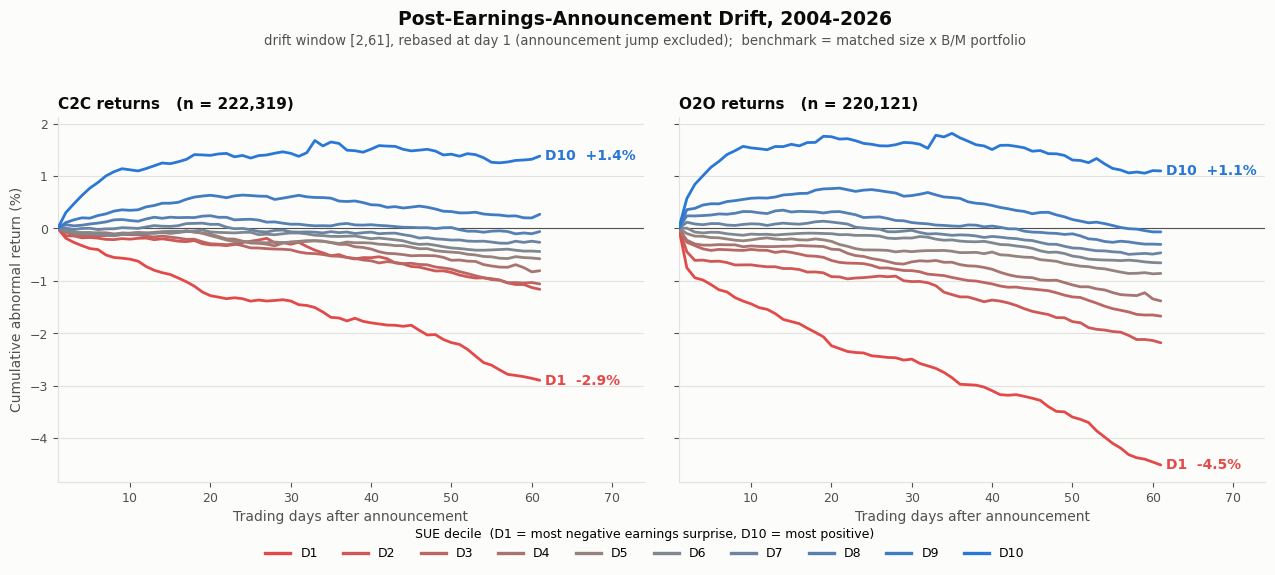

In [4]:
plot_full(Y0, Y1)

### A.3 补充：全样本 1996-2026

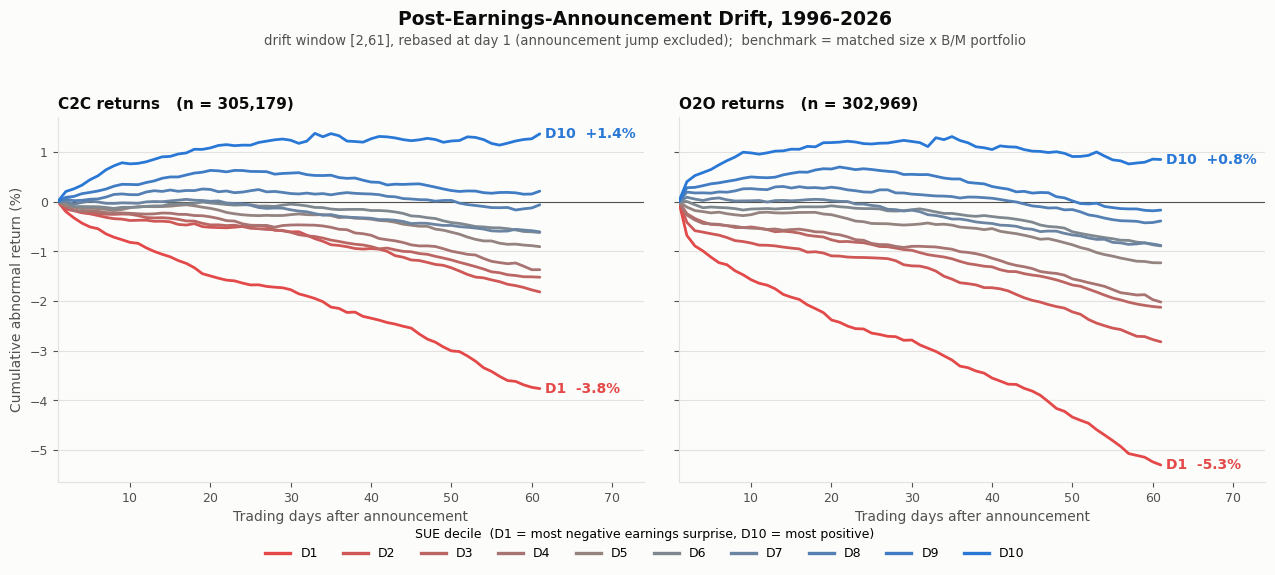

In [5]:
plot_full(*FULL)

### A.4 分时段（2004-2026，6 个四年段）

/home/zan1/ipykernel_703453/2281354002.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


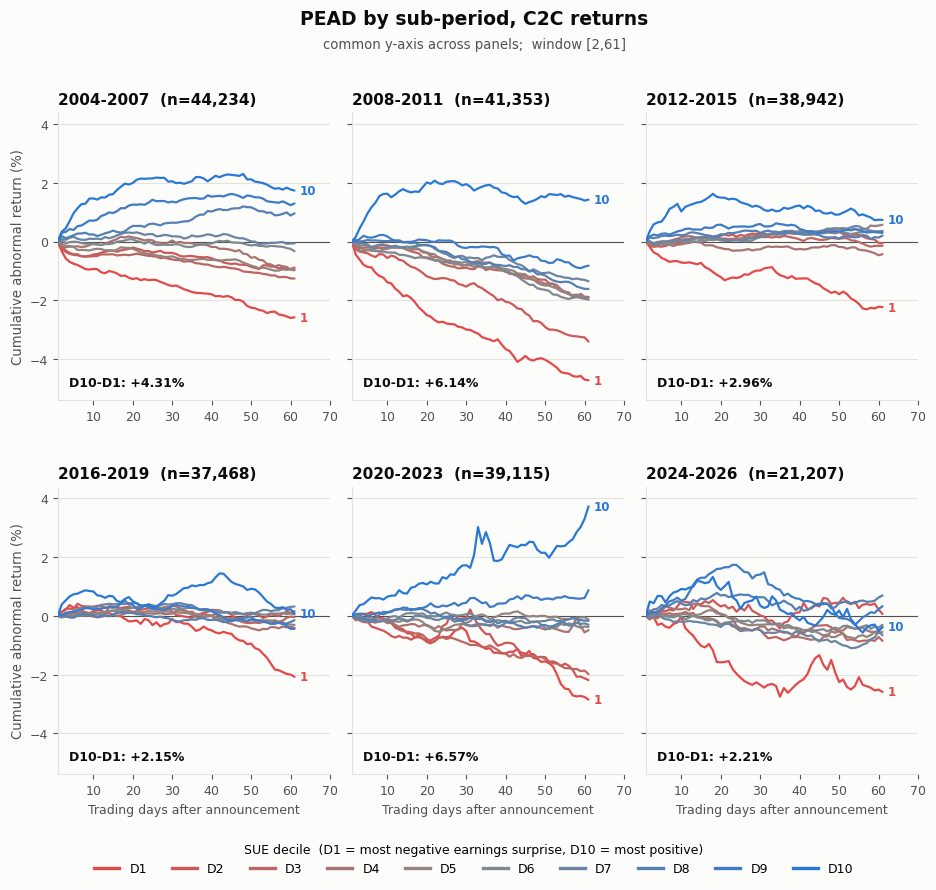

/home/zan1/ipykernel_703453/2281354002.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


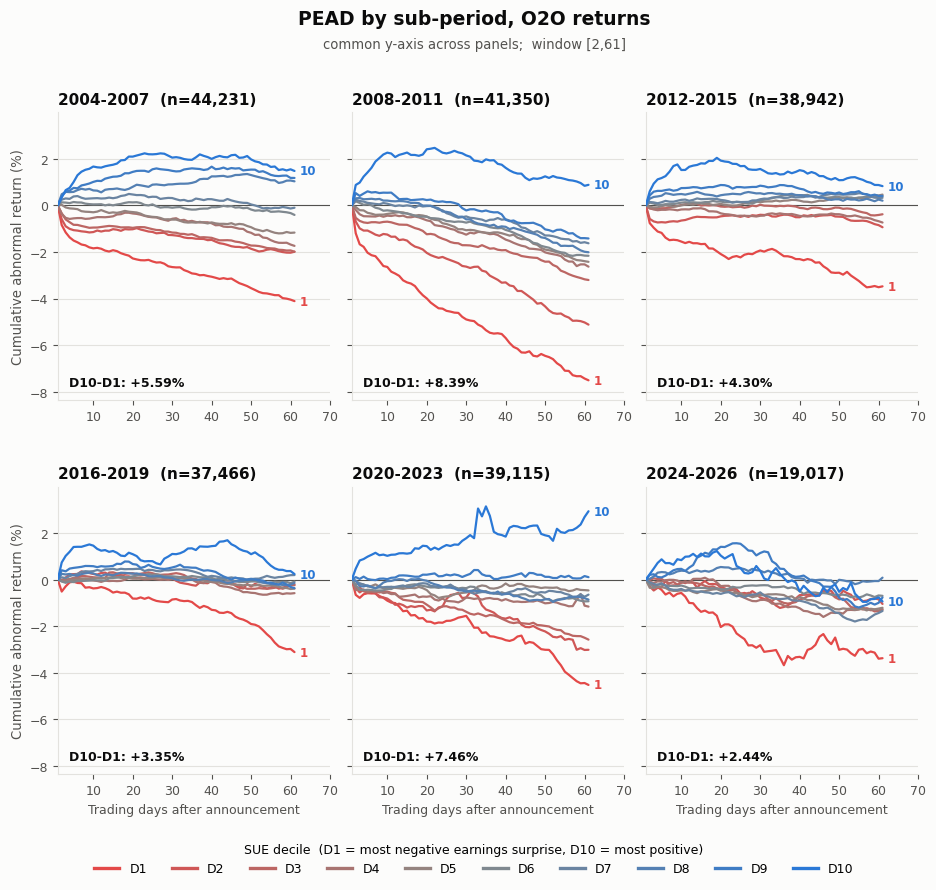

In [6]:
plot_periods()

### A.5 数字表

In [7]:
display(table())

,C2C_d1,C2C_d30,C2C_d61,C2C_n,O2O_d1,O2O_d30,O2O_d61,O2O_n
period,,,,,,,,
2004-2026,0.0,2.82,4.28,222319,0.0,4.13,5.61,220121
1996-2026,0.0,3.01,5.13,305179,0.0,4.00,6.15,302969
2004-2007,0.0,3.56,4.31,44234,0.0,4.70,5.59,44231
2008-2011,0.0,4.94,6.14,41353,0.0,7.04,8.39,41350
2012-2015,0.0,2.15,2.96,38942,0.0,3.50,4.30,38942
2016-2019,0.0,0.79,2.15,37468,0.0,1.96,3.35,37466
2020-2023,0.0,2.24,6.57,39115,0.0,3.33,7.46,39115
2024-2026,0.0,2.69,2.21,21207,0.0,3.19,2.44,19017


### 补充细节图参考2020-2023

/home/zan1/ipykernel_703453/1211773275.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


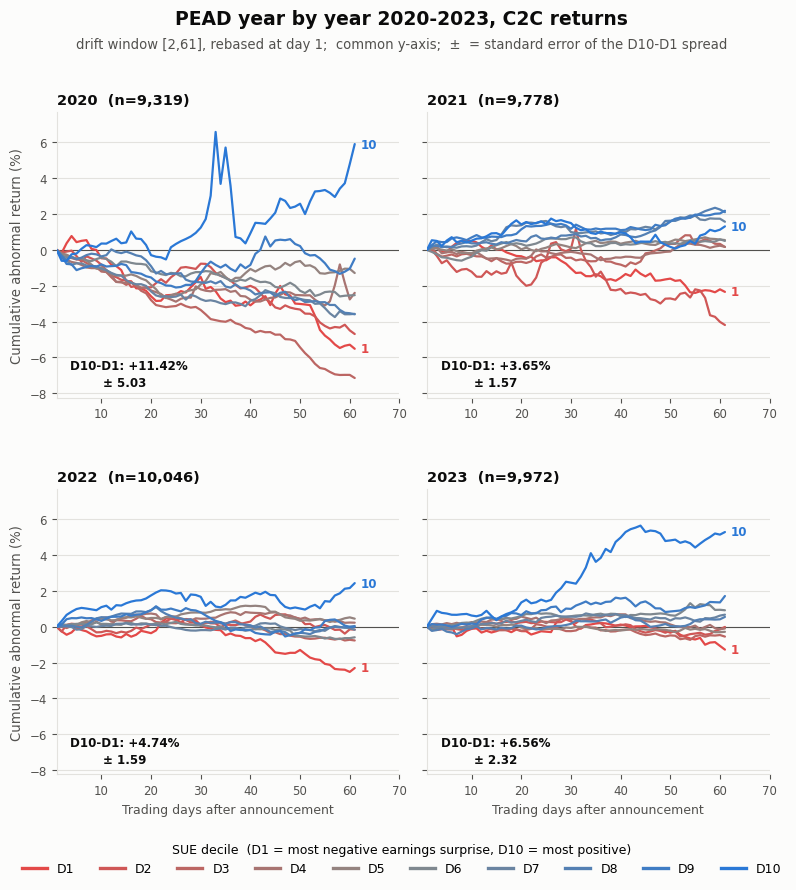

/home/zan1/ipykernel_703453/1211773275.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


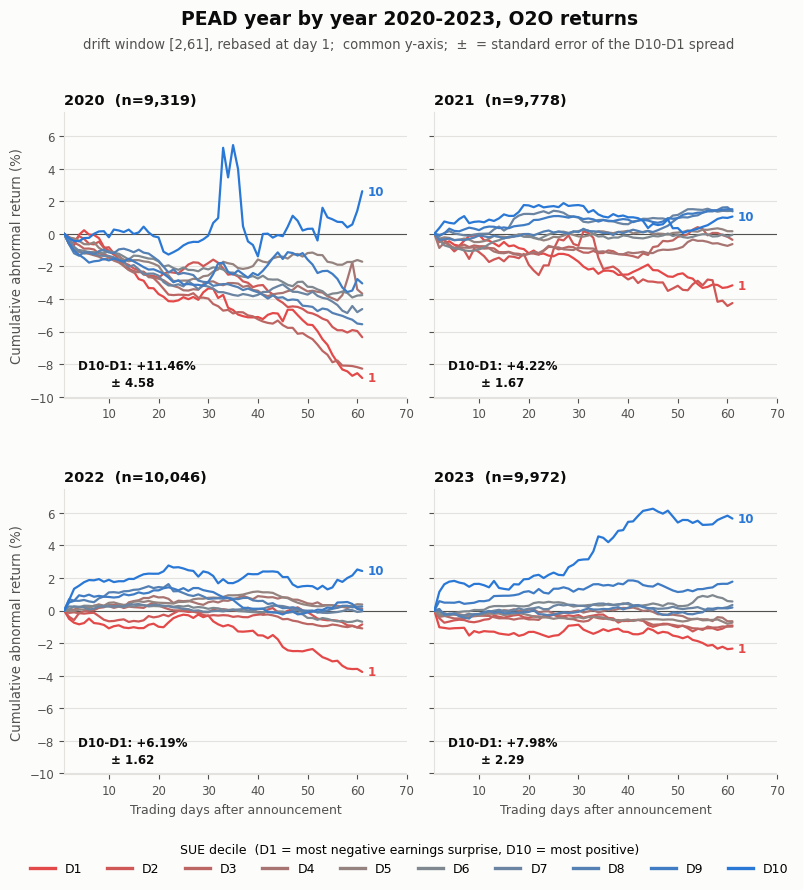

,C2C,C2C_se,C2C_t,n,O2O,O2O_se,O2O_t
period,,,,,,,
2020-2023,6.57,1.48,4.44,39115,7.46,1.39,5.35
2020,11.42,5.03,2.27,9319,11.46,4.58,2.50
2021,3.65,1.57,2.32,9778,4.22,1.67,2.53
2022,4.74,1.59,2.97,10046,6.19,1.62,3.83
2023,6.56,2.32,2.83,9972,7.98,2.29,3.49


In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BUILD = "build"
PERIODS = [(2020, 2020), (2021, 2021), (2022, 2022), (2023, 2023)]

z    = np.load(f"{BUILD}/car_path_events.npz")
ks   = np.arange(int(z["kmin"]), int(z["kmax"]) + 1)
dec  = z["sue_dec"]
_p   = pd.read_parquet(f"{BUILD}/pead_panel.parquet",
                       columns=["eid", "anndats", "sue_dec", "is_latest_pends_on_day"])
_ev  = _p[_p["sue_dec"].notna() & _p["is_latest_pends_on_day"]]
assert np.array_equal(_ev["eid"].to_numpy(), z["eid"]), "npz 与 panel 行序不一致"
year = _ev["anndats"].dt.year.to_numpy()

MATS = {"C2C": z["c2c"], "O2O": z["o2o"]}
i1, i61 = int(np.where(ks == 1)[0][0]), int(np.where(ks == 61)[0][0])

def curves(conv, y0, y1):
    """[2,61] 平均 CAR(%)，基线 day 1；返回 (曲线, n, D10-D1 的标准误)"""
    M = MATS[conv]
    m = (year >= y0) & (year <= y1) & ~np.isnan(dec) \
        & ~np.isnan(M[:, i1]) & ~np.isnan(M[:, i61])
    d = pd.DataFrame(M[m], columns=ks); d["_dec"] = dec[m]
    g = d.groupby("_dec").mean().T * 100
    g.columns = [int(c) for c in g.columns]
    v = (M[m, i61] - M[m, i1]) * 100; dd = dec[m]
    hi, lo = v[dd == 10], v[dd == 1]
    se = np.sqrt(hi.var(ddof=1) / len(hi) + lo.var(ddof=1) / len(lo))
    return g.loc[1:] - g.loc[1], int(m.sum()), se

RAMP   = LinearSegmentedColormap.from_list("sue", ["#e34948", "#8a8a86", "#2a78d6"])
COLORS = {d: RAMP((d - 1) / 9) for d in range(1, 11)}
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2de"
handles = [plt.Line2D([], [], color=COLORS[d], lw=2.4) for d in range(1, 11)]

NC = int(np.ceil(len(PERIODS) / 2))
for conv in ("C2C", "O2O"):
    segs = [(f"{a}-{b}" if a != b else f"{a}",) + curves(conv, a, b) for a, b in PERIODS]
    lo_ = min(s[1].values.min() for s in segs); hi_ = max(s[1].values.max() for s in segs)
    pad = (hi_ - lo_) * 0.08
    fg, axs = plt.subplots(2, NC, figsize=(3.4 * NC + 2.4, 8.6), sharey=True,
                           facecolor=SURFACE, gridspec_kw={"wspace": 0.08, "hspace": 0.32})
    axs = np.atleast_2d(axs)
    for ax, (lab, d, n, se) in zip(axs.ravel(), segs):
        ax.set_facecolor(SURFACE); ax.axhline(0, color=INK2, lw=0.8, zorder=1)
        for dd in range(1, 11):
            ax.plot(d.index, d[dd], color=COLORS[dd], lw=1.6,
                    solid_capstyle="round", zorder=3)
        for dd in (10, 1):
            ax.annotate(f"{dd}", xy=(61, d[dd].iloc[-1]), xytext=(4, 0),
                        textcoords="offset points", color=COLORS[dd], fontsize=8.5,
                        fontweight="bold", va="center")
        spread = d[10].iloc[-1] - d[1].iloc[-1]
        ax.annotate(f"D10-D1: {spread:+.2f}%\n        ± {se:.2f}", xy=(0.04, 0.04),
                    xycoords="axes fraction", fontsize=8.5, color=INK,
                    fontweight="bold", linespacing=1.4)
        ax.set_xlim(1, 70); ax.set_ylim(lo_ - pad, hi_ + pad)
        ax.set_title(f"{lab}  (n={n:,})", color=INK, fontsize=10.5,
                     fontweight="bold", loc="left", pad=6)
        ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
        for s_ in ("top", "right"):   ax.spines[s_].set_visible(False)
        for s_ in ("left", "bottom"): ax.spines[s_].set_color(GRID)
        ax.tick_params(colors=INK2, labelsize=8.5)
    for ax in axs.ravel()[len(segs):]:
        ax.set_visible(False)
    for ax in axs[-1]:
        if ax.get_visible():
            ax.set_xlabel("Trading days after announcement", color=INK2, fontsize=9)
    for ax in axs[:, 0]:
        ax.set_ylabel("Cumulative abnormal return (%)", color=INK2, fontsize=9.5)
    fg.legend(handles, [f"D{d}" for d in range(1, 11)], loc="lower center", ncol=10,
              frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02),
              title="SUE decile  (D1 = most negative earnings surprise, D10 = most positive)",
              title_fontsize=9)
    fg.suptitle(f"PEAD year by year 2020-2023, {conv} returns", fontsize=13.5,
                fontweight="bold", color=INK, x=0.5, y=1.0)
    fg.text(0.5, 0.955, "drift window [2,61], rebased at day 1;  common y-axis;  "
            "±  = standard error of the D10-D1 spread",
            ha="center", fontsize=9.5, color=INK2)
    fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()

rows = []
for a, b in [(2020, 2023)] + PERIODS:
    r = {"period": f"{a}-{b}" if a != b else f"{a}"}
    for conv in ("C2C", "O2O"):
        g, n, se = curves(conv, a, b); h = g[10] - g[1]
        r[f"{conv}"] = h.loc[61]; r[f"{conv}_se"] = se; r[f"{conv}_t"] = h.loc[61] / se
        r["n"] = n
    rows.append(r)
display(pd.DataFrame(rows).set_index("period").round(2))


# 如果补充1996-2026的分段图？

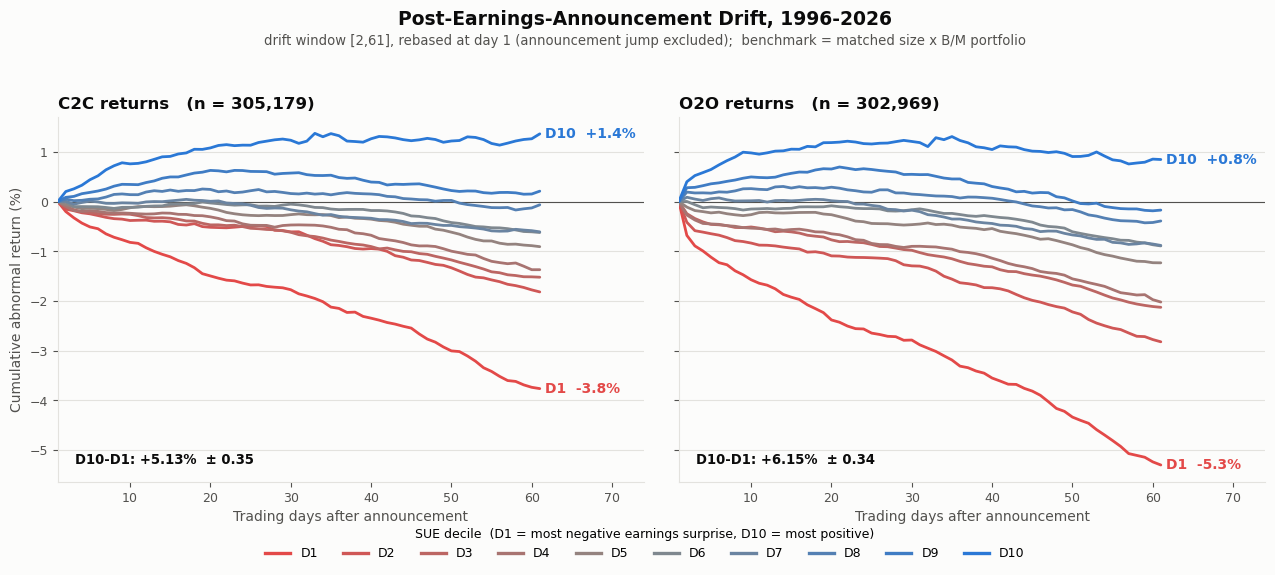

/home/zan1/ipykernel_703453/2884895048.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


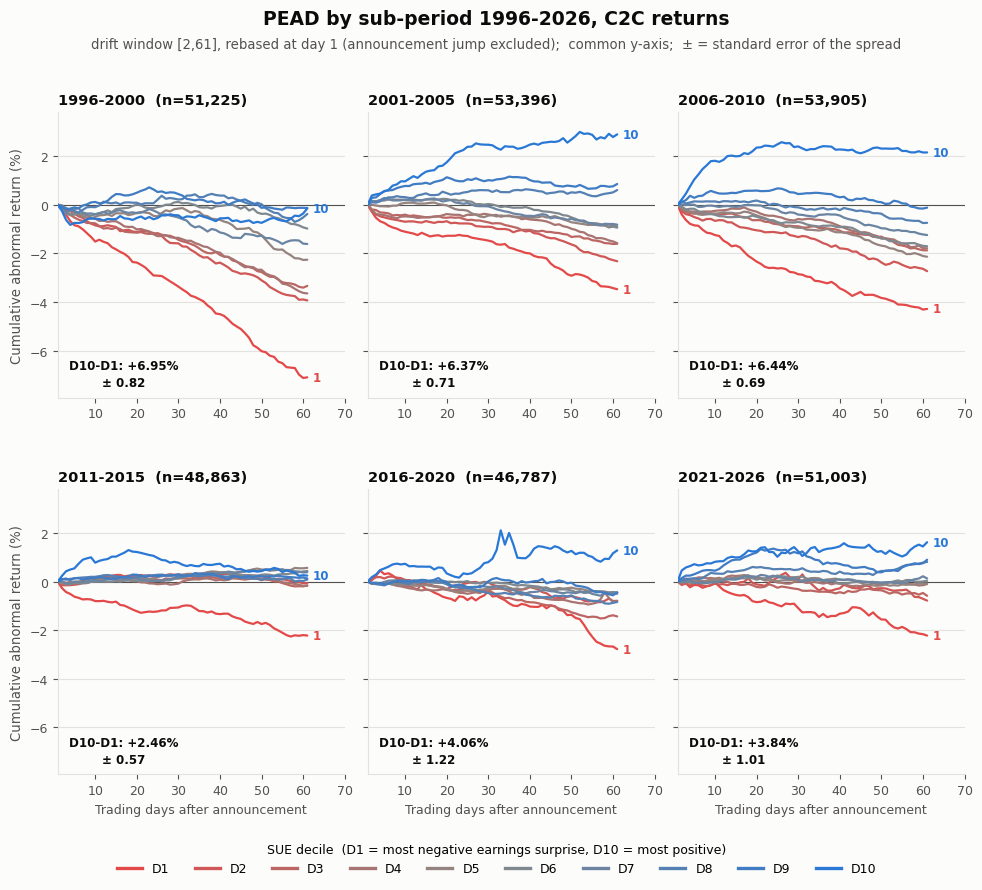

/home/zan1/ipykernel_703453/2884895048.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


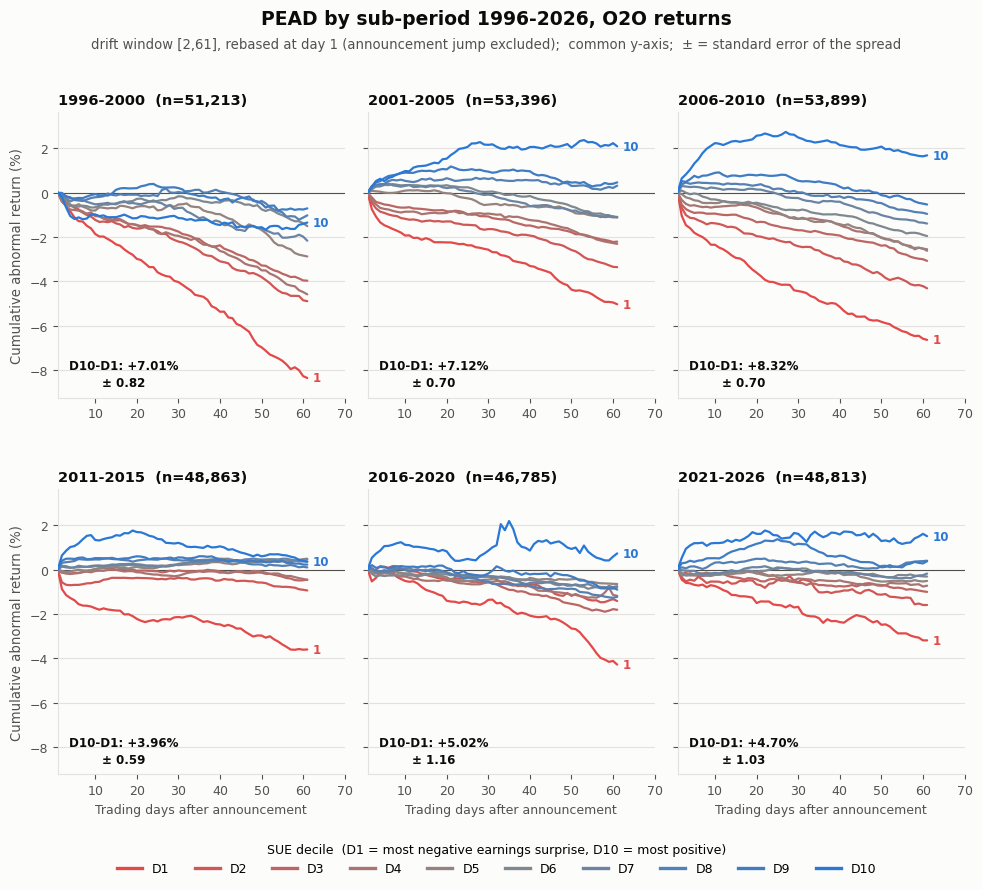

,C2C,C2C_se,C2C_t,n,O2O,O2O_se,O2O_t
period,,,,,,,
1996-2026,5.13,0.35,14.79,302969,6.15,0.34,17.94
1996-2000,6.95,0.82,8.43,51213,7.01,0.82,8.55
2001-2005,6.37,0.71,9.01,53396,7.12,0.70,10.13
2006-2010,6.44,0.69,9.34,53899,8.32,0.70,11.88
2011-2015,2.46,0.57,4.30,48863,3.96,0.59,6.75
2016-2020,4.06,1.22,3.32,46785,5.02,1.16,4.34
2021-2026,3.84,1.01,3.81,48813,4.70,1.03,4.56


In [16]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

BUILD   = "build"
Y0, Y1  = 1996, 2026
PERIODS = [(1996, 2000), (2001, 2005), (2006, 2010),
           (2011, 2015), (2016, 2020), (2021, 2026)]      # 6 段 × 5 年

z    = np.load(f"{BUILD}/car_path_events.npz")
ks   = np.arange(int(z["kmin"]), int(z["kmax"]) + 1)       # -60 … 61
dec  = z["sue_dec"]                                        # 当季截面十分位
_p   = pd.read_parquet(f"{BUILD}/pead_panel.parquet",
                       columns=["eid", "anndats", "sue_dec", "is_latest_pends_on_day"])
_ev  = _p[_p["sue_dec"].notna() & _p["is_latest_pends_on_day"]]
assert np.array_equal(_ev["eid"].to_numpy(), z["eid"]), "npz 与 panel 行序不一致"
year = _ev["anndats"].dt.year.to_numpy()

MATS    = {"C2C": z["c2c"], "O2O": z["o2o"]}
i1, i61 = int(np.where(ks == 1)[0][0]), int(np.where(ks == 61)[0][0])

def curves(conv, y0, y1):
    """漂移段 [2,61] 的平均 CAR(%)，基线 = 公告后第 1 日。
    返回 (event_day × decile 曲线, 事件数, D10-D1 的标准误)"""
    M = MATS[conv]
    m = (year >= y0) & (year <= y1) & ~np.isnan(dec) \
        & ~np.isnan(M[:, i1]) & ~np.isnan(M[:, i61])
    d = pd.DataFrame(M[m], columns=ks); d["_dec"] = dec[m]
    g = d.groupby("_dec").mean().T * 100
    g.columns = [int(c) for c in g.columns]
    v  = (M[m, i61] - M[m, i1]) * 100
    dd = dec[m]; hi, lo = v[dd == 10], v[dd == 1]
    se = np.sqrt(hi.var(ddof=1) / len(hi) + lo.var(ddof=1) / len(lo))
    return g.loc[1:] - g.loc[1], int(m.sum()), se

RAMP    = LinearSegmentedColormap.from_list("sue", ["#e34948", "#8a8a86", "#2a78d6"])
COLORS  = {d: RAMP((d - 1) / 9) for d in range(1, 11)}
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e3e2de"
handles = [plt.Line2D([], [], color=COLORS[d], lw=2.4) for d in range(1, 11)]
LEGT    = "SUE decile  (D1 = most negative earnings surprise, D10 = most positive)"
SUBT    = "drift window [2,61], rebased at day 1 (announcement jump excluded)"

def _dress(ax, title, fs=11):
    ax.set_facecolor(SURFACE); ax.axhline(0, color=INK2, lw=0.8, zorder=1)
    ax.set_title(title, color=INK, fontsize=fs, fontweight="bold", loc="left", pad=6)
    ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ("top", "right"):   ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9)

# ---------- 图 1：整段 1996-2026 ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=True, facecolor=SURFACE)
for ax, conv in zip(axes, ["C2C", "O2O"]):
    d, n, se = curves(conv, Y0, Y1)
    for dd in range(1, 11):
        ax.plot(d.index, d[dd], color=COLORS[dd], lw=2.0, solid_capstyle="round", zorder=3)
    for dd in (10, 1):
        ax.annotate(f"D{dd}  {d[dd].iloc[-1]:+.1f}%", xy=(61, d[dd].iloc[-1]), xytext=(4, 0),
                    textcoords="offset points", color=COLORS[dd], fontsize=10,
                    fontweight="bold", va="center")
    sp = d[10].iloc[-1] - d[1].iloc[-1]
    ax.annotate(f"D10-D1: {sp:+.2f}%  ± {se:.2f}", xy=(0.03, 0.05),
                xycoords="axes fraction", fontsize=9.5, color=INK, fontweight="bold")
    ax.set_xlim(1, 74)
    ax.set_xlabel("Trading days after announcement", color=INK2, fontsize=10)
    _dress(ax, f"{conv} returns   (n = {n:,})", fs=12)
axes[0].set_ylabel("Cumulative abnormal return (%)", color=INK2, fontsize=10)
fig.legend(handles, [f"D{d}" for d in range(1, 11)], loc="lower center", ncol=10,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04), title=LEGT, title_fontsize=9)
fig.suptitle(f"Post-Earnings-Announcement Drift, {Y0}-{Y1}",
             fontsize=13.5, fontweight="bold", color=INK, x=0.5, y=1.0)
fig.text(0.5, 0.935, f"{SUBT};  benchmark = matched size x B/M portfolio",
         ha="center", fontsize=9.5, color=INK2)
fig.tight_layout(rect=[0, 0.02, 1, 0.93]); plt.show()

# ---------- 图 2：6 个五年段 ----------
NC = int(np.ceil(len(PERIODS) / 2))
for conv in ("C2C", "O2O"):
    segs = [(f"{a}-{b}",) + curves(conv, a, b) for a, b in PERIODS]
    lo_ = min(s[1].values.min() for s in segs); hi_ = max(s[1].values.max() for s in segs)
    pad = (hi_ - lo_) * 0.08
    fg, axs = plt.subplots(2, NC, figsize=(3.1 * NC + 2.4, 8.6), sharey=True,
                           facecolor=SURFACE, gridspec_kw={"wspace": 0.08, "hspace": 0.32})
    axs = np.atleast_2d(axs)
    for ax, (lab, d, n, se) in zip(axs.ravel(), segs):
        for dd in range(1, 11):
            ax.plot(d.index, d[dd], color=COLORS[dd], lw=1.6,
                    solid_capstyle="round", zorder=3)
        for dd in (10, 1):
            ax.annotate(f"{dd}", xy=(61, d[dd].iloc[-1]), xytext=(4, 0),
                        textcoords="offset points", color=COLORS[dd], fontsize=8.5,
                        fontweight="bold", va="center")
        sp = d[10].iloc[-1] - d[1].iloc[-1]
        ax.annotate(f"D10-D1: {sp:+.2f}%\n        ± {se:.2f}", xy=(0.04, 0.04),
                    xycoords="axes fraction", fontsize=8.5, color=INK,
                    fontweight="bold", linespacing=1.4)
        ax.set_xlim(1, 70); ax.set_ylim(lo_ - pad, hi_ + pad)
        _dress(ax, f"{lab}  (n={n:,})", fs=10.5)
    for ax in axs.ravel()[len(segs):]:
        ax.set_visible(False)
    for ax in axs[-1]:
        if ax.get_visible():
            ax.set_xlabel("Trading days after announcement", color=INK2, fontsize=9)
    for ax in axs[:, 0]:
        ax.set_ylabel("Cumulative abnormal return (%)", color=INK2, fontsize=9.5)
    fg.legend(handles, [f"D{d}" for d in range(1, 11)], loc="lower center", ncol=10,
              frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02), title=LEGT, title_fontsize=9)
    fg.suptitle(f"PEAD by sub-period {Y0}-{Y1}, {conv} returns",
                fontsize=13.5, fontweight="bold", color=INK, x=0.5, y=1.0)
    fg.text(0.5, 0.955, f"{SUBT};  common y-axis;  ± = standard error of the spread",
            ha="center", fontsize=9.5, color=INK2)
    fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()

# ---------- 数字表 ----------
rows = []
for a, b in [(Y0, Y1)] + PERIODS:
    r = {"period": f"{a}-{b}"}
    for conv in ("C2C", "O2O"):
        g, n, se = curves(conv, a, b); h = g[10] - g[1]
        r[conv] = h.loc[61]; r[f"{conv}_se"] = se; r[f"{conv}_t"] = h.loc[61] / se
        r["n"] = n
    rows.append(r)
display(pd.DataFrame(rows).set_index("period").round(2))


---

## B. 含 day 1 的 `[1,61]`

基线放在公告日 day 0，drift 从 day 1 起算 —— BT1989 图 2 把公告日收益算进 pre 段、post 段从 day 1 开始（1989paper到 day 60，这里到 day 61）。


### B.1 设定（只换窗口）

In [ ]:
# 只换窗口口径；样式与 plot_full / plot_periods / table 沿用 A 段
WIN = "[1,61]"

def curves(conv, y0, y1):
    """[1,61] 的平均 CAR(%)，基线 = 公告日 day 0（含 day 1 的跳）"""
    M = MATS[conv]
    m = (year >= y0) & (year <= y1) & ~np.isnan(dec) \
        & ~np.isnan(M[:, i0]) & ~np.isnan(M[:, i61])
    d = pd.DataFrame(M[m], columns=ks); d["_dec"] = dec[m]
    g = d.groupby("_dec").mean().T * 100
    g.columns = [int(c) for c in g.columns]
    return g.loc[0:] - g.loc[0], d.groupby("_dec").size()

### B.2 整段 2004-2026（主设定）

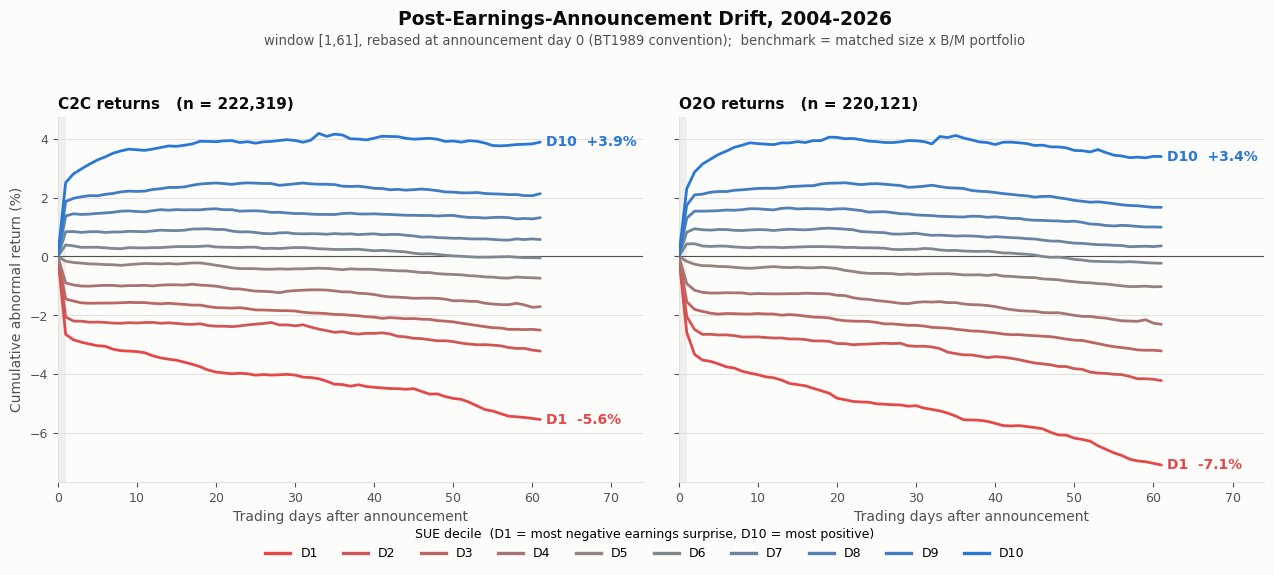

In [9]:
plot_full(Y0, Y1)

### B.3 补充：全样本 1996-2026

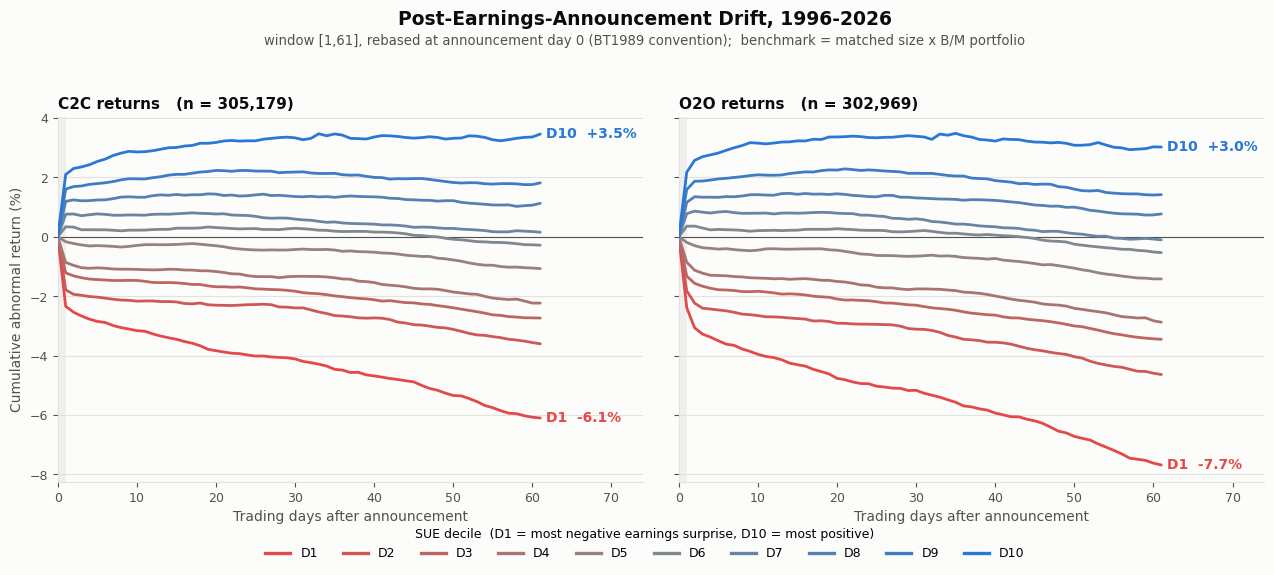

In [10]:
plot_full(*FULL)

### B.4 分时段（2004-2026，6 个四年段）

/home/zan1/ipykernel_703453/2281354002.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


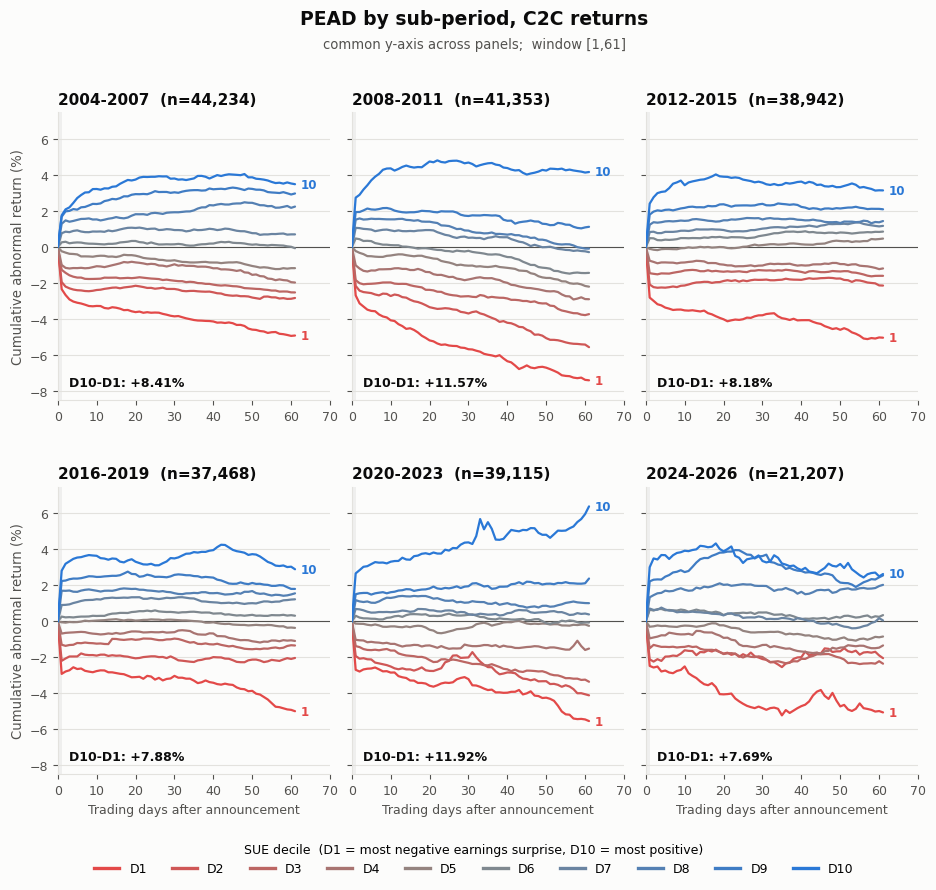

/home/zan1/ipykernel_703453/2281354002.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fg.tight_layout(rect=[0, 0.015, 1, 0.945]); plt.show()


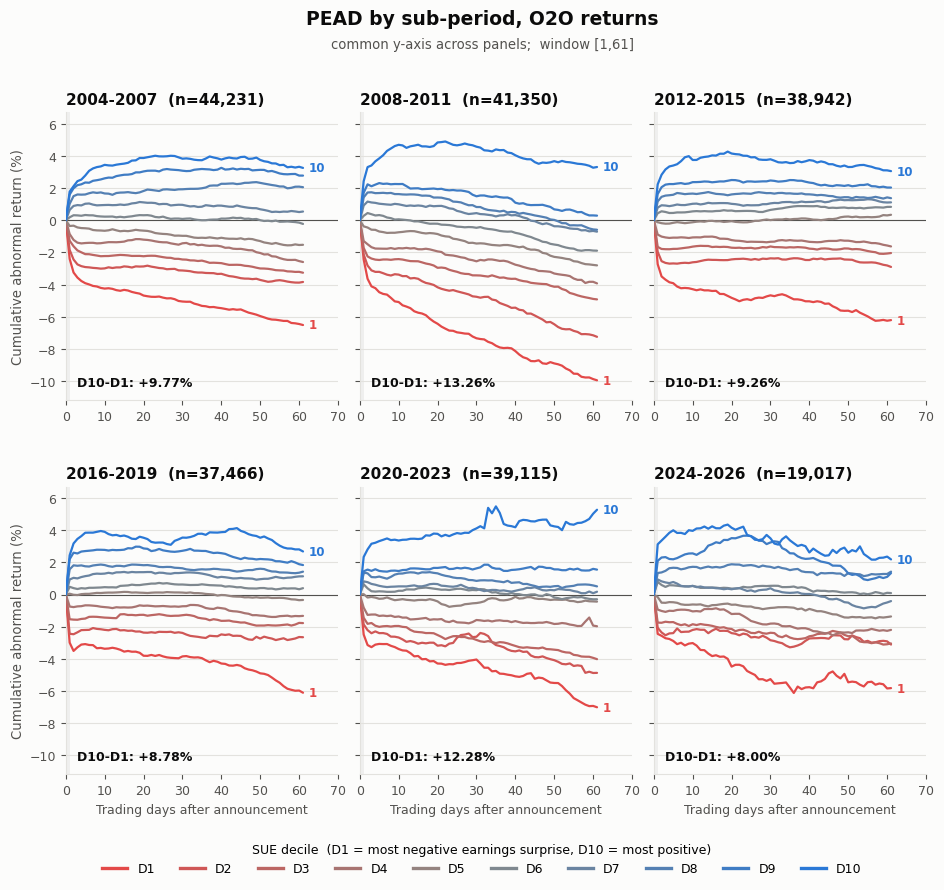

In [11]:
plot_periods()

### B.5 数字表

In [12]:
display(table())

,C2C_d1,C2C_d30,C2C_d61,C2C_n,O2O_d1,O2O_d30,O2O_d61,O2O_n
period,,,,,,,,
2004-2026,5.17,7.99,9.45,222319,4.89,9.02,10.50,220121
1996-2026,4.44,7.45,9.57,305179,4.56,8.56,10.71,302969
2004-2007,4.10,7.66,8.41,44234,4.18,8.88,9.77,44231
2008-2011,5.43,10.37,11.57,41353,4.87,11.91,13.26,41350
2012-2015,5.22,7.37,8.18,38942,4.96,8.46,9.26,38942
2016-2019,5.73,6.52,7.88,37468,5.43,7.39,8.78,37466
2020-2023,5.36,7.60,11.92,39115,4.82,8.16,12.28,39115
2024-2026,5.48,8.17,7.69,21207,5.57,8.76,8.00,19017
